## Proyecto Final - Analisis de Trafico de Red

###Objetivo
 Analizar un dataset de trafico de red para identificar patrones relevantes, evaluar la calidad de los datos, construir un modelo predictivo simple y proponer una aplicacion profesional del analisis en un contexto de ciberseguridad.
### Preguntas de trabajo
 - Que protocolos dominan el trafico observado?
 - Que nodos concentran la mayor parte de la comunicacion?
- Como se distribuye el tamano de los paquetes?
- Es posible predecir de forma simple el tamano del trafico a partir de variables basicas?

In [ ]:
from google.colab import files
import io
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Modelos y utilidades de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Configuración global de visualización
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
# ── Carga de datos ────────────────────────────────────────────────────────────
uploaded = files.upload()
file_name = next(iter(uploaded))
# Los encabezados originales de Wireshark se reemplazan por nombres en
# snake_case más descriptivos para facilitar el acceso programático.
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
df = df.rename(columns={
    "Time": "timestamp_rel",
    "Source": "source_ip",
    "No.": "packet_id",
    "Destination": "destination_ip",
    "Protocol": "protocol",
    "Length": "bytes_transferred",
    "Info": "info"
})
# ── Verificación inicial ──────────────────────────────────────────────────────
print(f"Archivo cargado: {file_name}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()


In [ ]:

# ── Limpieza de datos ─────────────────────────────────────────
# Se evaluan tres dimensiones de calidad antes de cualquier
# transformación: completitud (nulos), unicidad (duplicados) y distribución
# de las variables categóricas clave.
df.info()

# -- Nulos en variables críticas --------------------------------------------------
# Solo se validan las columnas que son requeridas para el análisis:
# origen del tráfico, instante de captura y volumen transferido.
# El modelo invalida el registro si encuentra un nulo.
critical_nulls = (
    df[["source_ip", "timestamp_rel", "bytes_transferred"]]
    .isna()
    .sum()
    .rename("nulos")
    .to_frame()
)


# -- Duplicados ----------------------------------------------------------------
# Se mide la duplicación en dos niveles :
#   1. Filas exactamente iguales en todas las columnas.
#   2. Colisiones en la clave natural (source_ip + timestamp_rel),
#      que pueden indicar retransmisiones o errores de captura.
duplicate_total = int(df.duplicated().sum())

duplicate_groups = (
    df.groupby(["source_ip", "timestamp_rel"], dropna=False)
    .size()
    .reset_index(name="duplicados_en_grupo")
)


# Se conservan solo los grupos con más de un paquete y se ordenan
# de mayor a menor para priorizar los casos más problemáticos.
duplicate_groups = duplicate_groups[duplicate_groups["duplicados_en_grupo"] > 1] \
    .sort_values("duplicados_en_grupo", ascending=False)


# -- Distribución de variables categóricas ------------------------------------
# Las frecuencias de protocolo, IP origen e IP destino permiten detectar
# tráfico anómalo concentrado en pocas direcciones, ambos relevantes para el
# preprocesamiento.
protocol_counts = df["protocol"].value_counts()
source_counts = df["source_ip"].value_counts()
destination_counts = df["destination_ip"].value_counts()

print("\nNulos en campos criticos:")
display(critical_nulls)



# ── Resultados ─────────────────────────────────────────────────────
print(f"Duplicados exactos totales: {duplicate_total:,}")
print(f"Grupos duplicados por source_ip + timestamp_rel: {len(duplicate_groups):,}")
print(f"Tamanio maximo de grupo duplicado: {duplicate_groups['duplicados_en_grupo'].max() if len(duplicate_groups) else 1}")

print("\nTop 10 protocolos:")
display(protocol_counts.head(10).to_frame("frecuencia"))

print("\nTop 10 source_ip:")
display(source_counts.head(10).to_frame("frecuencia"))

print("\nTop 10 destination_ip:")
display(destination_counts.head(10).to_frame("frecuencia"))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 394136 entries, 0 to 394135
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp_rel      394136 non-null  float64
 1   source_ip          394136 non-null  object 
 2   packet_id          394136 non-null  int64  
 3   destination_ip     394136 non-null  object 
 4   protocol           394136 non-null  object 
 5   bytes_transferred  394136 non-null  int64  
 6   info               394136 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 21.0+ MB

Nulos en campos criticos:


,nulos
source_ip,0
timestamp_rel,0
bytes_transferred,0


Duplicados exactos totales: 0
Grupos duplicados por source_ip + timestamp_rel: 48
Tamanio maximo de grupo duplicado: 2

Top 10 protocolos:


,frecuencia
protocol,
TCP,314873
TLSv1.3,71625
ICMP,2690
DNS,1999
TLSv1.2,1763
ARP,447
OCSP,258
NBNS,231
RARP,178



Top 10 source_ip:


,frecuencia
source_ip,
192.167.7.162,116067
104.91.166.75,57238
74.125.9.169,37085
23.33.29.79,25918
173.194.133.202,22832
104.91.166.113,18222
192.232.16.76,15245
108.156.172.107,10986
192.232.16.205,8076



Top 10 destination_ip:


,frecuencia
destination_ip,
192.167.7.162,276849
104.91.166.75,15565
23.33.29.79,10538
74.125.9.169,6800
173.194.133.202,6451
146.75.78.73,6116
104.91.166.113,5200
192.232.16.76,4514
192.232.16.205,4274


## Hallazgos iniciales y calidad de datos

El dataset contiene **394,136 registros** y **7 columnas**, por lo que ofrece una base amplia para un analisis exploratorio de trafico de red. Las variables mas relevantes para este estudio son `source_ip`, `destination_ip`, `protocol`, `timestamp_rel` y `bytes_transferred`.

En la revision de calidad, los campos criticos `source_ip`, `timestamp_rel` y `bytes_transferred` no presentan valores nulos. Ademas, no se detectan duplicados exactos de fila completa. Sin embargo, si aparecen **48 grupos repetidos** al combinar `source_ip` y `timestamp_rel`, con un maximo de **2 registros por grupo**, lo que sugiere eventos muy cercanos o simultaneos y no necesariamente un error estructural.

En terminos operativos, esto indica que el dataset es consistente para trabajar analisis descriptivos, visualizaciones y un modelo base. Tambien es importante notar que `timestamp_rel` representa tiempo relativo de captura y no una fecha calendario real, por lo que se interpreta mejor como secuencia temporal del trafico.


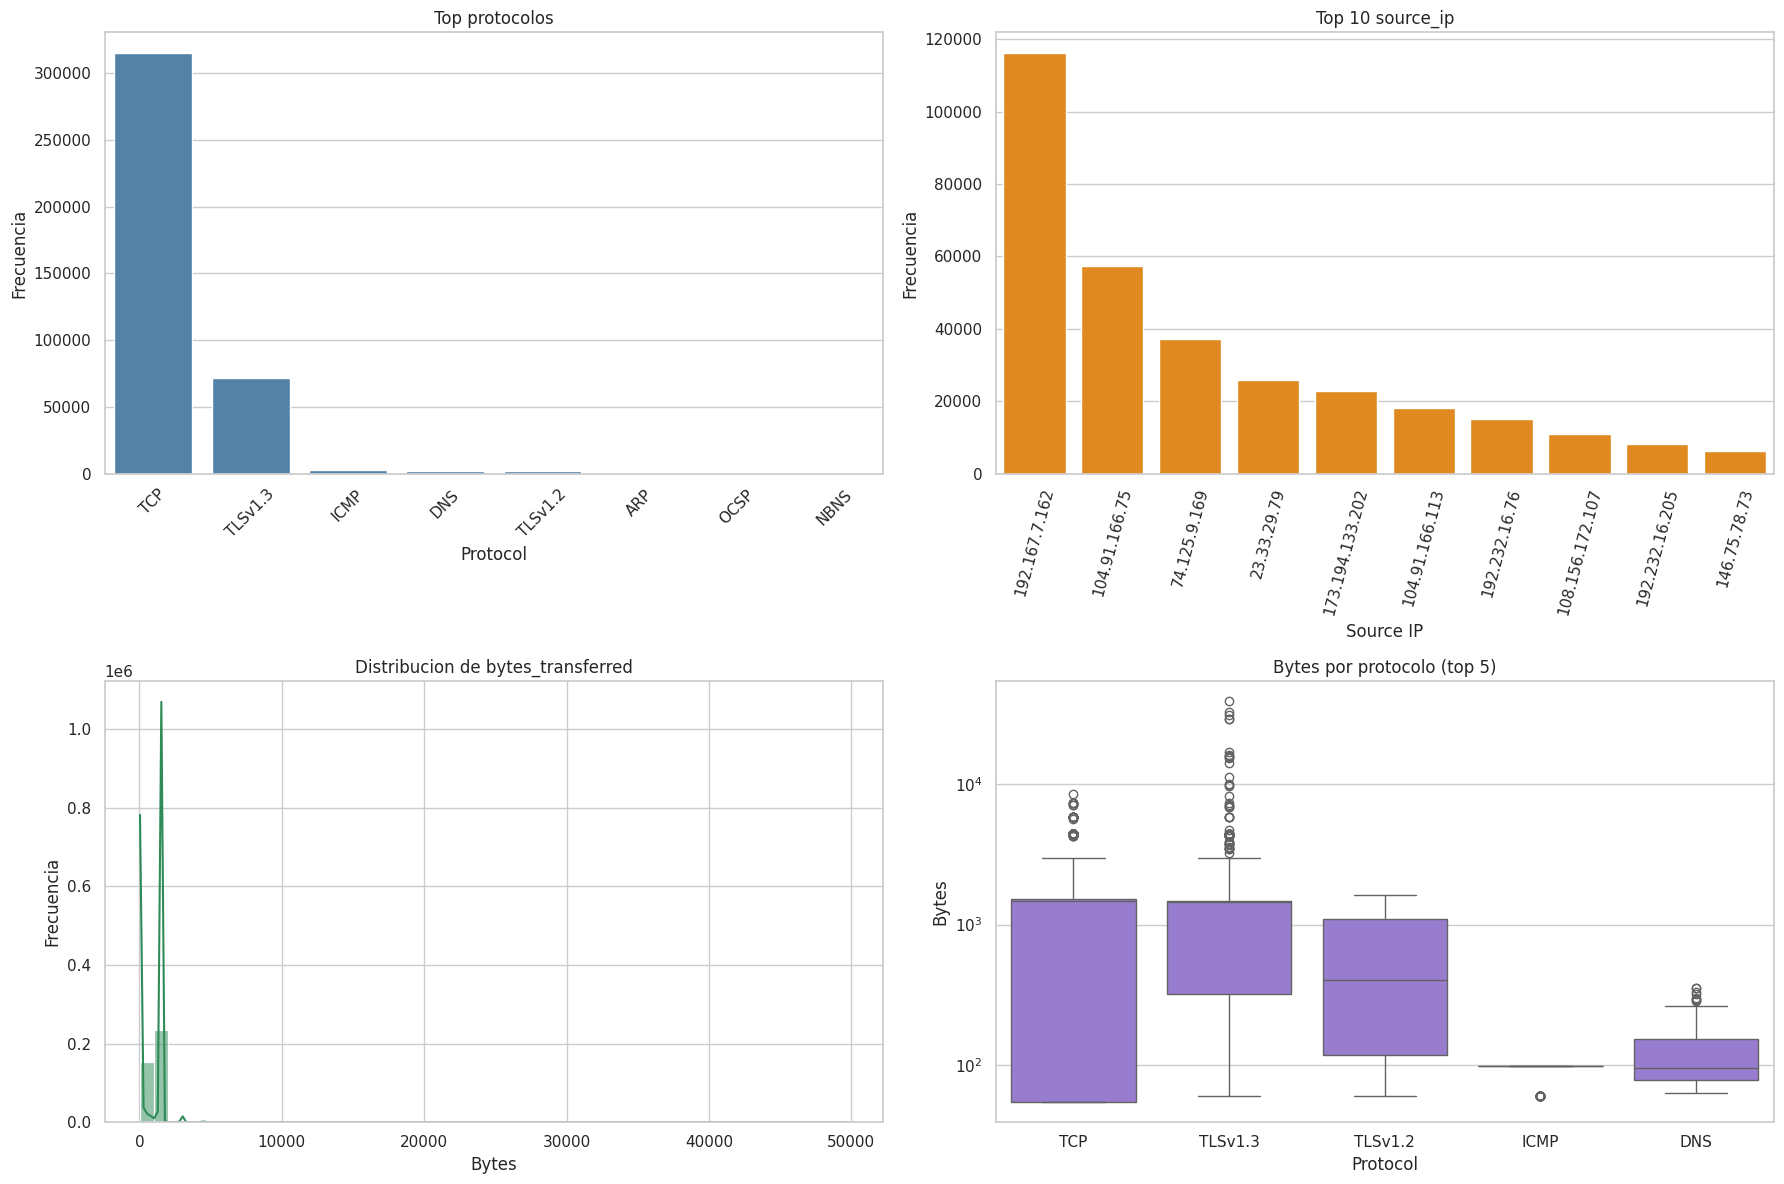

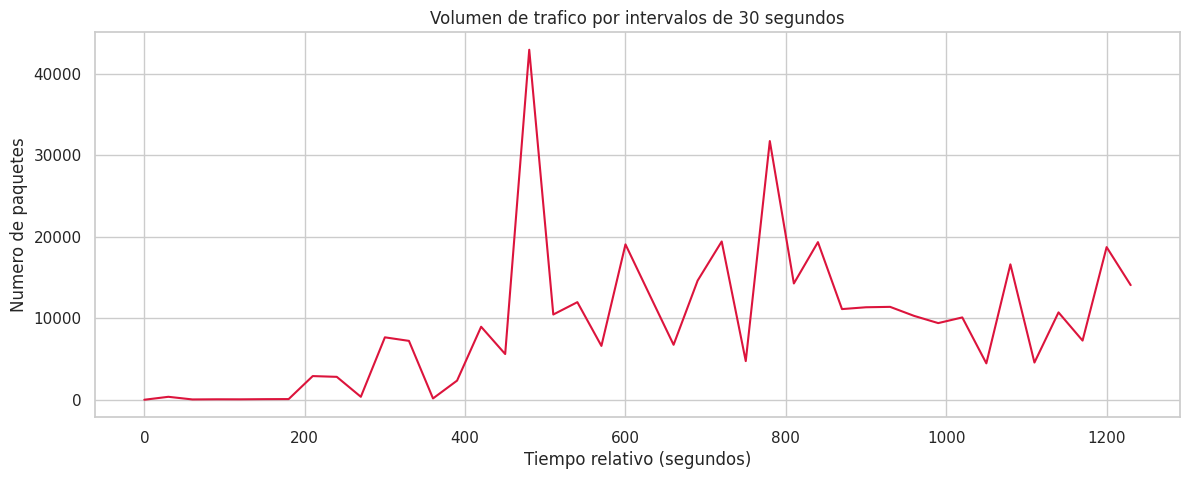

In [ ]:
# ── Análisis exploratorio de los datos ───────────────────────────────────────
# Se generan cinco gráficas agrupadas en dos figuras:
#   Figura 1 (2×2): distribución de protocolos, IPs origen, tamaño de paquetes
#                   y dispersión de bytes por protocolo.
#   Figura 2:       evolución temporal del volumen de tráfico.

# -- Agregación temporal ------------------------------------------------------
# timestamp_rel se agrupa en ventanas de 30 segundos para suavizar picos
# puntuales y poder observar tendencias de volumen a lo largo de la captura.
df["time_bin_30s"] = (df["timestamp_rel"] // 30) * 30
traffic_by_time = df.groupby("time_bin_30s").size().reset_index(name="num_packets")

top_protocols = df["protocol"].value_counts().head(5).index
boxplot_sample = df[df["protocol"].isin(top_protocols)].sample(
    n=min(50000, len(df[df["protocol"].isin(top_protocols)])),
    random_state=42
)

# ── Figura 1: distribución de variables clave ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# [0,0] Frecuencia de los 8 protocolos más comunes
# Permite identificar si el tráfico está dominado por uno o dos protocolos.
sns.barplot(
    x=protocol_counts.head(8).index,
    y=protocol_counts.head(8).values,
    ax=axes[0, 0],
    color="steelblue"
)
axes[0, 0].set_title("Top protocolos")
axes[0, 0].set_xlabel("Protocol")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].tick_params(axis="x", rotation=45)

# [0,1] Top 10 IPs de origen
# Una IP con frecuencia muy superior al resto puede indicar un escáner,
# un servidor muy activo o tráfico anómalo.
sns.barplot(
    x=source_counts.head(10).index,
    y=source_counts.head(10).values,
    ax=axes[0, 1],
    color="darkorange"
)
axes[0, 1].set_title("Top 10 source_ip")
axes[0, 1].set_xlabel("Source IP")
axes[0, 1].set_ylabel("Frecuencia")
axes[0, 1].tick_params(axis="x", rotation=75)

# [1,0] Distribución de tamaño de paquetes con KDE superpuesto
# La mayoría del tráfico TCP/IP genera una distribución bimodal:
# paquetes de control pequeños (ACK, SYN) y paquetes de datos más grandes.
sns.histplot(
    df["bytes_transferred"],
    bins=50,
    kde=True,
    ax=axes[1, 0],
    color="seagreen"
)
axes[1, 0].set_title("Distribucion de bytes_transferred")
axes[1, 0].set_xlabel("Bytes")
axes[1, 0].set_ylabel("Frecuencia")

# [1,1] Dispersión de bytes por protocolo (escala logarítmica)
# La escala log es necesaria porque bytes_transferred tiene outliers extremos
# que aplastarían la visualización en escala lineal.
sns.boxplot(
    data=boxplot_sample,
    x="protocol",
    y="bytes_transferred",
    ax=axes[1, 1],
    color="mediumpurple"
)
axes[1, 1].set_title("Bytes por protocolo (top 5)")
axes[1, 1].set_xlabel("Protocol")
axes[1, 1].set_ylabel("Bytes")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()


# ── Figura 2: evolución temporal del tráfico ──────────────────────────────────
# Muestra cómo varía el número de paquetes capturados a lo largo del tiempo.
# Picos abruptos pueden corresponder a ráfagas de retransmisiones, escaneos
# de puertos u otros eventos de red relevantes para el análisis.
plt.figure(figsize=(14, 5))
sns.lineplot(data=traffic_by_time, x="time_bin_30s", y="num_packets", color="crimson")
plt.title("Volumen de trafico por intervalos de 30 segundos")
plt.xlabel("Tiempo relativo (segundos)")
plt.ylabel("Numero de paquetes")
plt.show()


Resultados del modelo:


,Metrica,Valor
0,MAE,241.009445
1,RMSE,558.930396
2,R2,0.543915


Coeficientes positivos mas altos:


,feature,coef
31,cat__destination_ip_146.75.78.73,2378.344422
33,cat__destination_ip_192.167.7.162,467.336638
19,cat__source_ip_108.156.172.107,253.524082
13,cat__protocol_TCP,253.143872
24,cat__source_ip_192.232.16.76,240.555295
23,cat__source_ip_192.232.16.205,236.920455
25,cat__source_ip_23.33.29.79,232.140041
21,cat__source_ip_173.194.133.202,215.611094
26,cat__source_ip_74.125.9.169,212.551794
16,cat__protocol_TLSv1.3,206.878114


Coeficientes negativos mas bajos:


,feature,coef
20,cat__source_ip_146.75.78.73,-1107.473887
36,cat__destination_ip_23.33.29.79,-375.233111
22,cat__source_ip_192.167.7.162,-372.727981
29,cat__destination_ip_104.91.166.75,-341.222241
35,cat__destination_ip_192.232.16.76,-339.054767
30,cat__destination_ip_108.156.172.107,-338.733202
37,cat__destination_ip_74.125.9.169,-336.476276
32,cat__destination_ip_173.194.133.202,-331.668909
34,cat__destination_ip_192.232.16.205,-331.424459
28,cat__destination_ip_104.91.166.113,-304.611616


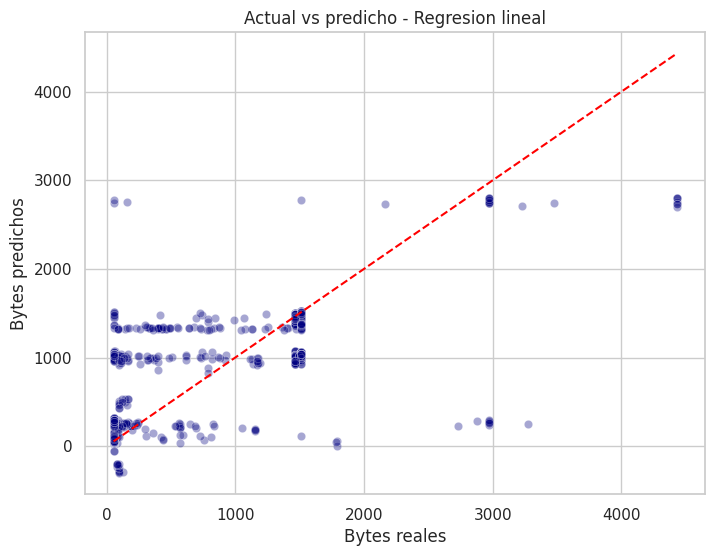

In [ ]:
# ── Modelado predictivo: regresión lineal sobre bytes_transferred ─────────────
# El objetivo es predecir el tamaño de cada paquete a partir de su protocolo,
# IPs de origen/destino y momento de captura.

df_model = df.copy()

# -- Reducción de cardinalidad ------------------------------------------------
# source_ip y destination_ip pueden tener miles de valores únicos, lo que
# dispararía las columnas tras el One-Hot Encoding. Se conservan solo las
# 10 IPs más frecuentes de cada campo y el resto se agrupa bajo "Other".
for col, top_n in [("source_ip", 10), ("destination_ip", 10)]:
    top_values = df_model[col].value_counts().head(top_n).index
    df_model[col] = df_model[col].where(df_model[col].isin(top_values), "Other")


# -- Definición de features y variable objetivo -------------------------------
X = df_model[["timestamp_rel", "protocol", "source_ip", "destination_ip"]]
y = df_model["bytes_transferred"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -- Pipeline de preprocesamiento ---------------------------------------------
# Las numéricas se imputan con la mediana (robusta a outliers de bytes).
# Las categóricas se imputan con la moda y luego se codifican con OHE;
# handle_unknown="ignore" evita errores si el test contiene IPs no vistas.
numeric_features = ["timestamp_rel"]
categorical_features = ["protocol", "source_ip", "destination_ip"]

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])


# -- Entrenamiento ------------------------------------------------------------
model = Pipeline([
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)



# -- Evaluación ---------------------------------------------------------------
# MAE reporta el error promedio en bytes (interpretable en la escala original).
# RMSE penaliza más los errores grandes, útil dado que bytes_transferred
# tiene outliers pronunciados. R² indica qué proporción de la varianza explica
# el modelo; valores bajos sugerirían que la relación no es lineal.
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metrica": ["MAE", "RMSE", "R2"],
    "Valor": [mae, rmse, r2]
})

print("Resultados del modelo:")
display(metrics_df)


# -- Análisis de coeficientes -------------------------------------------------
# Los coeficientes más positivos corresponden a los factores que más aumentan
# el tamaño predicho del paquete; los más negativos, a los que más lo reducen.
# Es una forma rápida de ver qué protocolo o IP domina la predicción.
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": model.named_steps["regressor"].coef_
})

print("Coeficientes positivos mas altos:")
display(coef_df.sort_values("coef", ascending=False).head(10))

print("Coeficientes negativos mas bajos:")
display(coef_df.sort_values("coef", ascending=True).head(10))


# -- Gráfica actual vs. predicho ----------------------------------------------
# Se muestrea un máximo de 2 000 puntos para que el scatter sea legible.
# La línea diagonal roja es la referencia perfecta (predicho == real);
# cuanto más se alejen los puntos de ella, mayor es el error del modelo.
plot_df = pd.DataFrame({
    "actual": y_test.values,
    "predicho": y_pred
}).sample(n=min(2000, len(y_test)), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="actual", y="predicho", alpha=0.35, color="navy")
plt.plot(
    [plot_df["actual"].min(), plot_df["actual"].max()],
    [plot_df["actual"].min(), plot_df["actual"].max()],
    color="red",
    linestyle="--"
)
plt.title("Actual vs predicho - Regresion lineal")
plt.xlabel("Bytes reales")
plt.ylabel("Bytes predichos")
plt.show()


## Interpretacion del modelo predictivo

Para esta etapa se eligio una **regresion lineal** como modelo base, con el objetivo de predecir `bytes_transferred` a partir del tiempo relativo, el protocolo y versiones simplificadas de las direcciones de origen y destino. La eleccion del modelo responde a un criterio de simplicidad e interpretabilidad, adecuado para una primera aproximacion predictiva.

Con este dataset, el modelo obtiene aproximadamente:
- **MAE = 241.01**
- **RMSE = 558.93**
- **R2 = 0.5439**

Estos resultados muestran un desempeno intermedio: el modelo capta una parte importante de la variabilidad del tamano de los paquetes, pero no toda. En otras palabras, existe una relacion observable entre el tamano del trafico y variables como el protocolo o ciertos nodos, aunque todavia queda una porcion relevante sin explicar. Esto es razonable, ya que el trafico de red depende de muchos factores adicionales que no estan incluidos en este modelo base.

La lectura de coeficientes permite ver que algunas combinaciones de protocolo y destinos aportan positivamente a la prediccion de paquetes mas grandes, mientras que otras se asocian con trafico mas pequeno o de control. Por eso, la regresion lineal funciona bien como **linea base interpretable**, pero no debe considerarse un modelo final de produccion.

## Aplicacion profesional del analisis

Este enfoque tiene una aplicacion directa en ciberseguridad y monitoreo de redes. En un entorno profesional, serviria para construir una **linea base de comportamiento normal** del trafico y comparar nuevos eventos contra ese patron esperado. Si ciertos nodos, protocolos o tamanos de paquete se desvían de forma marcada respecto al comportamiento habitual, esos casos podrian marcarse para revision.

En un SOC, en auditorias de seguridad o en administracion de infraestructura, este analisis seria util para:
- identificar hosts con actividad inusualmente alta,
- detectar concentraciones anormales de trafico,
- monitorear cambios en la distribucion de protocolos,
- y priorizar eventos potencialmente anómalos para investigacion.

De esta manera, el analisis exploratorio no solo describe el dataset, sino que se convierte en una base practica para decisiones de seguridad y observabilidad en redes reales.
